<a href="https://colab.research.google.com/github/omedel04/customer-churn-prediction/blob/main/Churn_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

print("Path to dataset files:", path)

In [ ]:
import os #to allow script to interact directly with operating system
import pandas as pd
dataset_path = "/root/.cache/kagglehub/datasets/muhammadshahidazeem/customer-churn-dataset/versions/1"
print("The files in the folder are:", os.listdir(dataset_path))
#loading the train data set(the ones with the answer)
train_df = pd.read_csv(os.path.join(dataset_path, 'customer_churn_dataset-training-master.csv'))
#loading the testing data set
test_df= pd.read_csv(os.path.join(dataset_path,'customer_churn_dataset-testing-master.csv'))
#printing how many rows and columns are available in the data
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

The files in the folder are: ['customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-training-master.csv']
Training data shape: (440833, 12)
Testing data shape: (64374, 12)


In [ ]:
train_df.info()
#reading traind_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [ ]:
train_df_cleaned=train_df.dropna()
print("Original shape:", train_df.shape)
print("Cleaned shape:", train_df_cleaned.shape)

Original shape: (440833, 12)
Cleaned shape: (440832, 12)


In [ ]:
# Check how many people stayed (0.0) vs left (1.0)
print(train_df_cleaned['Churn'].value_counts())

# Show it as percentages
print(train_df_cleaned['Churn'].value_counts(normalize=True) * 100)
#since the data set is more or less split failry equal we can proceed forward

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64
Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64


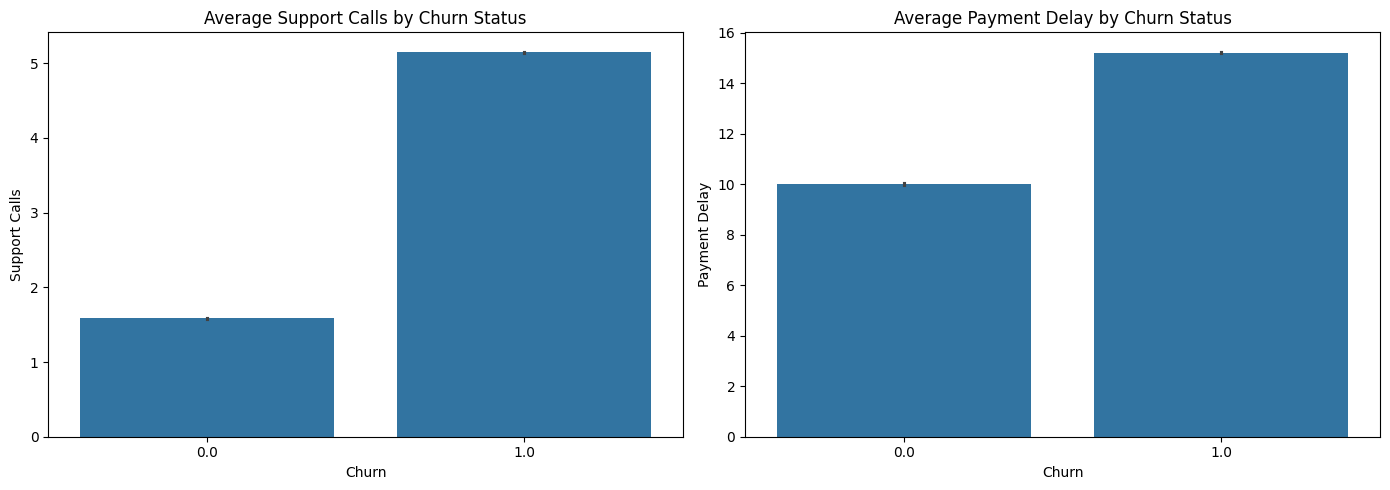

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create a 1-row, 2-column grid for two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average Support Calls for Stayed (0) vs Churned (1)
sns.barplot(x='Churn',y='Support Calls',data=train_df_cleaned,ax=axes[0])
axes[0].set_title('Average Support Calls by Churn Status')

# Chart 2: Average Payment Delay for Stayed (0) vs Churned (1)
sns.barplot(x='Churn',y='Payment Delay',data=train_df_cleaned,ax=axes[1])
axes[1].set_title('Average Payment Delay by Churn Status')
plt.tight_layout()
plt.show()

In [ ]:
#This would drop customer ID as its not really useful and would drop churn as thats what we're trynna figure out
X = train_df_cleaned.drop(columns=['CustomerID', 'Churn'])
#get dummies does one hot encoding which essentailly converts non numerical categories into numerical
X=pd.get_dummies(X,drop_first=True)
#Doing so stores our target answer key into y
y = train_df_cleaned['Churn']

X.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,True,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
#split data into 80% and 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training features shape:", X_train.shape)
print("Validation features shape:", X_val.shape)

Training features shape: (352665, 12)
Validation features shape: (88167, 12)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

#initializing the random forest model
model= RandomForestClassifier(n_estimators=100,random_state=42)
#training the model using the training set (clues + answer key)
model.fit(X_train,y_train)
#make predictions on the hidden validation set
y_pred=model.predict(X_val)
#compare predictions against the real answer key
print("Model Accuracy", accuracy_score(y_val,y_pred))
print("detailed reporting",classification_report(y_val,y_pred))


Model Accuracy 0.9996143681876439
detailed reporting               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38063
         1.0       1.00      1.00      1.00     50104

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [ ]:
#drops customer and churn from testing data
X_test=test_df.drop(columns=['CustomerID','Churn'])
#one hot encoding
X_test=pd.get_dummies(X,drop_first=True)
#make predictions using our trained random forest model
test_df['Predicted_Churn']=model.predict(X_test)
# 4. Save your final results to a new CSV file!
test_df.to_csv('final_churn_predictions.csv', index=False)

print(" DONE! Predictions generated and saved to 'final_churn_predictions.csv'")


 DONE! Predictions generated and saved to 'final_churn_predictions.csv'
